In [52]:
import psutil 
import platform 
import os
env_name = os.environ.get('CONDA_DEFAULT_ENV')
print("当前 conda 环境名：", env_name)
print(platform.system()) # 操作系统名称 
print(platform.release()) # 操作系统版本 
print(platform.machine()) # 计算机架构 
print(platform.processor()) # 处理器类型 
# CPU 信息 
print(psutil.cpu_count()) # CPU 核数 
print(psutil.cpu_freq()) # CPU 频率 
# 内存信息 
print(psutil.virtual_memory()) # 内存总量、可用内存、已用内存等

当前 conda 环境名： D:\python\cjl
Windows
11
AMD64
Intel64 Family 6 Model 154 Stepping 3, GenuineIntel
16
scpufreq(current=2500.0, min=0.0, max=2500.0)
svmem(total=16858828800, available=4141260800, percent=75.4, used=12717568000, free=4141260800)


In [3]:
import numpy as np

a = np.array([2, -1, 3])
b = np.array([1, 4, -2])
A = np.array([[1, 0, 2],[-1, 3, 1]])
B = np.array([[2, 1],[0, -1],[3, 2]])

# 1. 向量点积
dot_ab = np.dot(a, b)
print("1.  a·b =", dot_ab)

# 2. 矩阵乘法
AB = np.dot(A, B)  
print("2.   A × B =\n", AB)
print("   结果矩阵形状 =", AB.shape)

# 3. 向量 a 的 Frobenius 范数
norm_a = np.linalg.norm(a)
print("3.  向量 a 的 Frobenius 范数 =", norm_a)

1.  a·b = -8
2.   A × B =
 [[ 8  5]
 [ 1 -2]]
   结果矩阵形状 = (2, 2)
3.  向量 a 的 Frobenius 范数 = 3.7416573867739413


In [6]:
# 2.2 编程题
np.random.seed(50)
X = np.random.randn(3, 4)
Y = np.ones((4, 2))
Z = X @ Y
print("1.  X =",X)
print("2.  Y =",Y)
print("3.  Z =X × Y =",Z)
print("4.  Z[0,1] =", Z[0, 1])
print("    Z第2行 =", Z[1, :])
print("5.  ||Z||_F =", np.linalg.norm(Z))

1.  X = [[-1.56035211 -0.0309776  -0.62092842 -1.46458049]
 [ 1.41194612 -0.47673214 -0.78046921  1.07026774]
 [-1.2822926  -1.3274789   0.12633764  0.86219372]]
2.  Y = [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]
3.  Z =X × Y = [[-3.67683862 -3.67683862]
 [ 1.2250125   1.2250125 ]
 [-1.62124014 -1.62124014]]
4.  Z[0,1] = -3.676838621239437
    Z第2行 = [1.2250125 1.2250125]
5.  ||Z||_F = 5.9410802836425445


In [7]:
# 3.1 理论计算题
P_disease = 0.001   # 患病概率
P_no_disease = 1-P_disease
P_pos_given_disease = 0.99   # 灵敏度
P_pos_given_no = 0.02

# 计算阳性概率
P_pos = P_pos_given_disease * P_disease + P_pos_given_no * P_no_disease
# 计算患病概率
P_disease_given_pos = (P_pos_given_disease * P_disease) / P_pos
print(f"P(阳性) = {P_pos}")
print(f"P(患病|阳性) = {P_disease_given_pos}")

P(阳性) = 0.020970000000000003
P(患病|阳性) = 0.047210300429184546


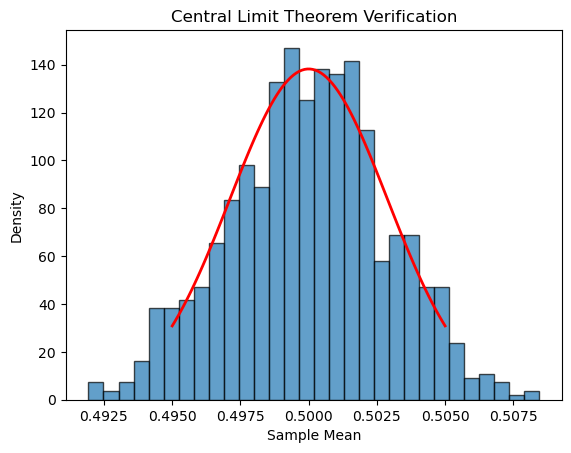

实际方差 = 0.00000828


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

n, m = 10000, 1000
np.random.seed(42)

# 1. 生成 m 个均值
means = [np.random.uniform(0, 1, n).mean() for _ in range(m)]

# 2. 直方图 + 正态分布
plt.hist(means, bins=30, density=True, alpha=0.7, edgecolor='black')
x = np.linspace(0.495, 0.505, 100)
plt.plot(x, stats.norm.pdf(x, 0.5, np.sqrt(1/12/n)), 'r-', linewidth=2)
plt.xlabel('Sample Mean')   # 样本均值
plt.ylabel('Density')       # 密度
plt.title('Central Limit Theorem Verification')
plt.show()

# 3. 实际方差
actual_var = np.var(means)
print(f"实际方差 = {actual_var:.8f}")

In [ ]:
# 4.1 理论计算题 - 梯度计算
x1, x2, y = 2, 1, 3
w1, w2 = 0.5, 1

z = (w1*x1 + w2*x2 - y)**2
dz_dw1 = 2 * (w1*x1 + w2*x2 - y) * x1
dz_dw2 = 2 * (w1*x1 + w2*x2 - y) * x2

print("∂z/∂w1 = 2*(w1*x1 + w2*x2 - y)*x1")
print("∂z/∂w2 = 2*(w1*x1 + w2*x2 - y)*x2")
print("当w1=0.5, w2=1 时:")
print("∂z/∂w1 =", dz_dw1)
print("∂z/∂w2 =", dz_dw2)

∂z/∂w1 = 2*(w1*x1 + w2*x2 - y)*x1
∂z/∂w2 = 2*(w1*x1 + w2*x2 - y)*x2
w1=0.5, w2=1 时:
∂z/∂w1 = -4.0
∂z/∂w2 = -2.0


In [27]:
# 4.2 手动实现计算图反向传播
import torch

# 手动前向计算
x, w1, w2 = 2, 1.5, 0.5
a = x * w1
b = a + w2
L = b ** 2
print(f"前向计算结果: L = {L}")

# 链式法则
# dL/db = 2*b
# db/da = 1
# da/dw1 = x
# db/dw2 = 1
dL_db = 2 * b
dL_dw1 = dL_db * 1 * x  # dL/db * db/da * da/dw1
dL_dw2 = dL_db * 1      # dL/db * db/dw2
print(f"计算梯度:")
print(f"∂L/∂w1 = {dL_dw1}")
print(f"∂L/∂w2 = {dL_dw2}")

# 自动微分验证（PyTorch）
w1_t = torch.tensor(1.5, requires_grad=True)
w2_t = torch.tensor(0.5, requires_grad=True)
x_t = torch.tensor(2.0)

a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t ** 2
L_t.backward()

print(f"自动微分梯度:")
print(f"∂L/∂w1 = {w1_t.grad.item()}")
print(f"∂L/∂w2 = {w2_t.grad.item()}")

# 验证一致性
tolerance = 1e-6
dw1_match = abs(dL_dw1 - w1_t.grad.item()) < tolerance
dw2_match = abs(dL_dw2 - w2_t.grad.item()) < tolerance

if dw1_match and dw2_match:
    print("计算与自动微分结果一致")
else:
    print("计算与自动微分结果不一致")
   

前向计算结果: L = 12.25
计算梯度:
∂L/∂w1 = 14.0
∂L/∂w2 = 7.0
自动微分梯度:
∂L/∂w1 = 14.0
∂L/∂w2 = 7.0
计算与自动微分结果一致


In [32]:
# 5.1 线性回归梯度推导
print("均方误差损失: L = (1/n) * Σ(y_i - (wx_i + b))²")
print("偏导表达式:")
print("∂L/∂w = (2/n) * Σ (y_i - (wx_i + b)) * (-x_i)")
print("      = -(2/n) * Σ x_i * (y_i - (wx_i + b))")
print("∂L/∂b = (2/n) * Σ (y_i - (wx_i + b)) * (-1)")
print("      = -(2/n) * Σ (y_i - (wx_i + b))")

均方误差损失: L = (1/n) * Σ(y_i - (wx_i + b))²
偏导表达式:
∂L/∂w = (2/n) * Σ (y_i - (wx_i + b)) * (-x_i)
      = -(2/n) * Σ x_i * (y_i - (wx_i + b))
∂L/∂b = (2/n) * Σ (y_i - (wx_i + b)) * (-1)
      = -(2/n) * Σ (y_i - (wx_i + b))


训练集: (1437, 64), 测试集: (360, 64)
批量大小: 32, 学习率: 0.1, 轮数: 50
epoch   1, loss: 0.9344, train_acc: 0.9353, test_acc: 0.9222
epoch   2, loss: 0.3828, train_acc: 0.9506, test_acc: 0.9361
epoch   3, loss: 0.2800, train_acc: 0.9589, test_acc: 0.9361
epoch   4, loss: 0.2324, train_acc: 0.9659, test_acc: 0.9500
epoch   5, loss: 0.2023, train_acc: 0.9701, test_acc: 0.9556
epoch   6, loss: 0.1812, train_acc: 0.9749, test_acc: 0.9583
epoch   7, loss: 0.1656, train_acc: 0.9749, test_acc: 0.9611
epoch   8, loss: 0.1534, train_acc: 0.9763, test_acc: 0.9611
epoch   9, loss: 0.1436, train_acc: 0.9777, test_acc: 0.9611
epoch  10, loss: 0.1351, train_acc: 0.9777, test_acc: 0.9639
epoch  11, loss: 0.1280, train_acc: 0.9805, test_acc: 0.9639
epoch  12, loss: 0.1217, train_acc: 0.9826, test_acc: 0.9639
epoch  13, loss: 0.1165, train_acc: 0.9840, test_acc: 0.9639
epoch  14, loss: 0.1117, train_acc: 0.9847, test_acc: 0.9639
epoch  15, loss: 0.1073, train_acc: 0.9861, test_acc: 0.9639
epoch  16, loss: 0.1034, t

C:\Users\86157\AppData\Local\Temp\ipykernel_12896\3071889486.py:132: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\86157\AppData\Local\Temp\ipykernel_12896\3071889486.py:132: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\86157\AppData\Local\Temp\ipykernel_12896\3071889486.py:132: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\86157\AppData\Local\Temp\ipykernel_12896\3071889486.py:132: UserWarning: Glyph 30830 (\N{CJK UNIFIED IDEOGRAPH-786E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\86157\AppData\Local\Temp\ipykernel_12896\3071889486.py:132: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\86157\AppData\Local\Temp\ipykernel_12896\3071889486.py:132: UserWarning: Glyph 27

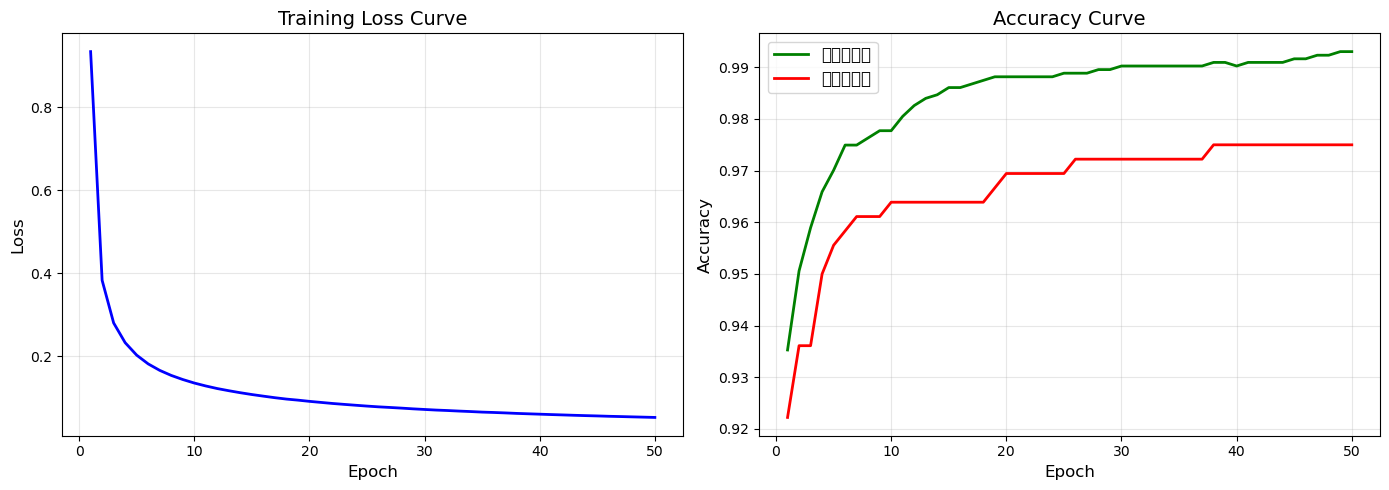

In [43]:
# 小批量随机梯度下降训练 Softmax 回归（每轮都输出并绘图）
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 加载数据
digits = load_digits()
X, y = digits.data, digits.target
X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# One-hot 编码
def one_hot(y, num_classes=10):
    n = len(y)
    onehot = np.zeros((n, num_classes))
    for i in range(n):
        onehot[i, y[i]] = 1
    return onehot

y_train_onehot = one_hot(y_train)
print(f"训练集: {X_train.shape}, 测试集: {X_test.shape}")

# Softmax 和损失函数
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy(y_pred, y_true):
    return -np.mean(np.sum(y_true * np.log(y_pred + 1e-8), axis=1))

# 初始化参数
input_dim = 64
num_classes = 10
lr = 0.1
batch_size = 32
num_epochs = 50

# 数据迭代器
def data_iter(X, y, batch_size):
    num_examples = len(X)
    indices = list(range(num_examples))
    np.random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = indices[i:min(i + batch_size, num_examples)]
        yield X[batch_indices], y[batch_indices]

# 训练函数
def train_sgd(lr, batch_size, num_epochs, X_train, y_train_onehot, y_train_raw, X_test, y_test_raw):
    w = np.random.randn(input_dim, num_classes) * 0.01
    b = np.zeros(num_classes)
    
    # 记录训练过程
    epoch_list = []
    loss_list = []
    train_acc_list = []
    test_acc_list = []
    
    for epoch in range(num_epochs):
        total_loss = 0
        num_batches = 0
        
        for X_batch, y_batch in data_iter(X_train, y_train_onehot, batch_size):
            # 前向传播
            z = X_batch @ w + b
            y_pred = softmax(z)
            
            # 计算损失
            loss = cross_entropy(y_pred, y_batch)
            total_loss += loss
            num_batches += 1
            
            # 反向传播
            n = X_batch.shape[0]
            grad_w = (X_batch.T @ (y_pred - y_batch)) / n
            grad_b = np.mean(y_pred - y_batch, axis=0)
            
            # 更新参数
            w -= lr * grad_w
            b -= lr * grad_b
        
        # 记录每个epoch的结果
        avg_loss = total_loss / num_batches
        train_pred = np.argmax(softmax(X_train @ w + b), axis=1)
        train_acc = np.mean(train_pred == y_train_raw)
        test_pred = np.argmax(softmax(X_test @ w + b), axis=1)
        test_acc = np.mean(test_pred == y_test_raw)
        
        epoch_list.append(epoch + 1)
        loss_list.append(avg_loss)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        
        # 每个epoch都输出
        print(f'epoch {epoch+1:3d}, loss: {avg_loss:.4f}, train_acc: {train_acc:.4f}, test_acc: {test_acc:.4f}')
    
    return w, b, epoch_list, loss_list, train_acc_list, test_acc_list

# 训练模型

print(f'批量大小: {batch_size}, 学习率: {lr}, 轮数: {num_epochs}')
w, b, epochs, losses, train_accs, test_accs = train_sgd(lr, batch_size, num_epochs, 
                                                         X_train, y_train_onehot, y_train, 
                                                         X_test, y_test)

# 最终测试准确率
test_pred = np.argmax(softmax(X_test @ w + b), axis=1)
final_acc = np.mean(test_pred == y_test)

print(f'最终测试集准确率: {final_acc:.4f} ({final_acc*100:.2f}%)')

# 绘制训练曲线
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：Loss曲线
axes[0].plot(epochs, losses, 'b-', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training Loss Curve', fontsize=14)
axes[0].grid(True, alpha=0.3)

# 右图：准确率曲线
axes[1].plot(epochs, train_accs, 'g-', linewidth=2, label='训练准确率')
axes[1].plot(epochs, test_accs, 'r-', linewidth=2, label='测试准确率')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Accuracy Curve', fontsize=14)
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [46]:
# 6.1 最大似然估计推导
import numpy as np


print("1. 似然函数 L(μ, σ²):")
print("   L(μ, σ²) = ∏_{i=1}^n (1/√(2πσ²)) * exp(-(x_i - μ)²/(2σ²))")
print("            = (2πσ²)^(-n/2) * exp(-∑(x_i - μ)²/(2σ²))")

print("2. 对数似然 ℓ(μ, σ²):")
print("   ℓ(μ, σ²) = -n/2 * ln(2πσ²) - ∑(x_i - μ)²/(2σ²)")
print("   μ 的最大似然估计:")
print("   ∂ℓ/∂μ = ∑(x_i - μ)/σ² = 0")
print("    ∑(x_i - μ) = 0")
print("    ∑x_i - nμ = 0")
print("    μ̂ = (1/n) ∑x_i")

print("3. σ² 的最大似然估计:")
print("   ∂ℓ/∂σ² = -n/(2σ²) + ∑(x_i - μ)²/(2σ⁴) = 0")
print("     σ̂² = (1/n) ∑(x_i - μ̂)²")



1. 似然函数 L(μ, σ²):
   L(μ, σ²) = ∏_{i=1}^n (1/√(2πσ²)) * exp(-(x_i - μ)²/(2σ²))
            = (2πσ²)^(-n/2) * exp(-∑(x_i - μ)²/(2σ²))
2. 对数似然 ℓ(μ, σ²):
   ℓ(μ, σ²) = -n/2 * ln(2πσ²) - ∑(x_i - μ)²/(2σ²)
   μ 的最大似然估计:
   ∂ℓ/∂μ = ∑(x_i - μ)/σ² = 0
    ∑(x_i - μ) = 0
    ∑x_i - nμ = 0
    μ̂ = (1/n) ∑x_i
3. σ² 的最大似然估计:
   ∂ℓ/∂σ² = -n/(2σ²) + ∑(x_i - μ)²/(2σ⁴) = 0
     σ̂² = (1/n) ∑(x_i - μ̂)²


Epoch  200, Loss: 0.0208
Epoch  400, Loss: 0.0139
Epoch  600, Loss: 0.0111
Epoch  800, Loss: 0.0095
Epoch 1000, Loss: 0.0085
测试集准确率: 1.0000 (100.00%)


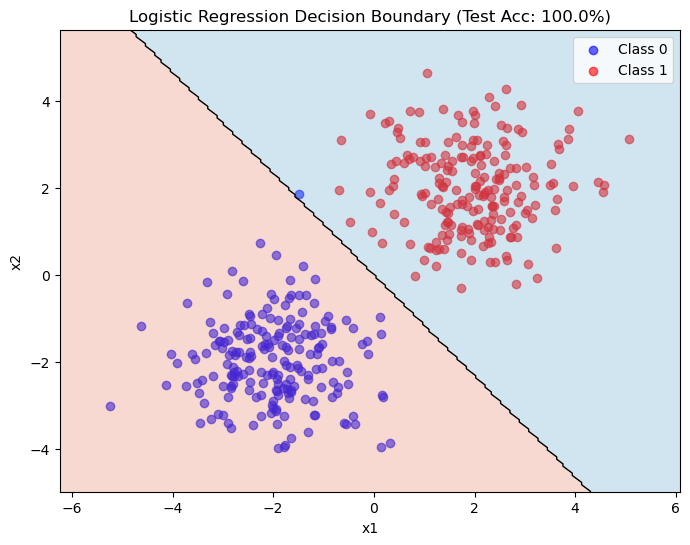

In [51]:
# 6.2 二分类逻辑回归
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# 1. 生成数据
def generate_data(n_samples, mean0, mean1):
    X0 = np.random.randn(n_samples, 2) + mean0
    X1 = np.random.randn(n_samples, 2) + mean1
    X = np.vstack([X0, X1])
    y = np.hstack([np.zeros(n_samples), np.ones(n_samples)])
    idx = np.random.permutation(len(y))
    return X[idx], y[idx]

X_train, y_train = generate_data(200, [-2, -2], [2, 2])
X_test, y_test = generate_data(100, [-2, -2], [2, 2])

# 2. sigmoid 和交叉熵损失
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y, y_pred):
    eps = 1e-8
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))

# 3. 梯度下降训练
w = np.zeros(2)
b = 0
lr = 0.1
epochs = 1000

for i in range(epochs):
    z = X_train @ w + b
    y_pred = sigmoid(z)
    
    loss = binary_cross_entropy(y_train, y_pred)
    
    dw = (X_train.T @ (y_pred - y_train)) / len(y_train)
    db = np.mean(y_pred - y_train)
    
    w -= lr * dw
    b -= lr * db
    
    if (i + 1) % 200 == 0:
        print(f"Epoch {i+1:4d}, Loss: {loss:.4f}")

# 4. 测试准确率
y_test_pred = (sigmoid(X_test @ w + b) >= 0.5).astype(int)
accuracy = np.mean(y_test_pred == y_test)
print(f"测试集准确率: {accuracy:.4f} ({accuracy*100:.2f}%)")

# 5. 绘制决策边界
plt.figure(figsize=(8, 6))
plt.scatter(X_train[y_train==0][:,0], X_train[y_train==0][:,1], c='blue', label='Class 0', alpha=0.6)
plt.scatter(X_train[y_train==1][:,0], X_train[y_train==1][:,1], c='red', label='Class 1', alpha=0.6)

x_min, x_max = X_train[:,0].min()-1, X_train[:,0].max()+1
y_min, y_max = X_train[:,1].min()-1, X_train[:,1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = sigmoid(np.c_[xx.ravel(), yy.ravel()] @ w + b)
Z = (Z >= 0.5).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
plt.contour(xx, yy, Z, colors='black', linewidths=1)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title(f'Logistic Regression Decision Boundary (Test Acc: {accuracy*100:.1f}%)')
plt.legend()
plt.show()

